In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
# Carrega dados 
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Carregamento bem-sucedido!")

Carregamento bem-sucedido!


In [3]:
# Visualização inicial
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1362,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6302,9250-WYPLL,Female,0,No,No,5,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,75.55,413.65,Yes
5271,6507-DTJZV,Male,0,No,Yes,13,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),66.40,831.75,No
1632,1899-VXWXM,Male,0,No,No,48,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),106.10,5082.8,Yes
2502,9067-YGSCA,Female,0,No,No,70,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),26.05,1856.4,No
5806,7854-EKTJL,Female,0,No,Yes,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.60,35.85,Yes
6701,0516-OOHAR,Male,0,Yes,Yes,28,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),100.35,2799,No
2426,1049-FYSYG,Female,0,Yes,No,17,No,No phone service,DSL,No,...,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),35.65,646.05,No
2921,0564-JJHGS,Male,0,No,No,9,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.50,829.1,Yes
1685,9365-SRSZE,Male,1,Yes,No,27,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.55,1943.9,No


In [4]:
# Muda índice 
df.set_index('customerID', inplace=True)
df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
3402-XRIUO,Female,1,Yes,No,22,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Month-to-month,Yes,Mailed check,63.55,1381.8,No
5685-IIXLY,Female,0,Yes,Yes,5,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,83.60,404.2,Yes
2237-ZFSMY,Female,0,No,No,39,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,No,One year,Yes,Electronic check,95.55,3692.85,Yes
6023-YEBUP,Male,0,No,No,3,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,Yes
3893-JRNFS,Male,0,No,No,68,No,No phone service,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),39.90,2796.35,No
2189-UXTKY,Female,0,Yes,No,22,Yes,Yes,DSL,Yes,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,79.20,1742.75,Yes
1134-YWTYF,Male,0,Yes,No,27,Yes,No,DSL,No,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,53.80,1389.85,No
4422-QVIJA,Female,0,No,Yes,35,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,50.15,1655.35,No
7134-MJPDY,Female,1,No,No,66,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),102.85,6976.75,No


**Tratamento de Dados**

In [5]:
# Contagem de valores nulos
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

A princípio, nenhum valor faltante

In [6]:
# Tipo de valor em cada coluna
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

O fato de TotalCharges estar assinalado como 'object' indica que há valores não numéricos.
Podemos forçar a conversão e identificar esses valores.

In [7]:
# Força conversão para número e identifica NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No


Há 11 instâncias com valores faltantes em TotalCharges. 
Note que todos são clientes não-idosos e recentes. Note ainda que todos permanecem na empresa. A hipótese aqui é de que os clientes ainda não foram efetivamente cobrados, e portanto não há registro de TotalCharges. 
Seguindo essa hipótese, imputaremos 0 em cada valor faltante.

In [8]:
# Preenche valores faltantes com 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isnull().sum()

np.int64(0)

É razoável verificar se não há valores incoerentes nas outras features, tendo em vista o caso da feature TotalCharges

In [9]:
# Contagem de cada ocorrência para cada variável
for feature in df.select_dtypes('object').columns:
    print(f"Feature: {feature}\n")
    print(df[feature].value_counts())
    print("\n")

Feature: gender

gender
Male      3555
Female    3488
Name: count, dtype: int64


Feature: Partner

Partner
No     3641
Yes    3402
Name: count, dtype: int64


Feature: Dependents

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


Feature: PhoneService

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


Feature: MultipleLines

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


Feature: InternetService

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Feature: OnlineSecurity

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


Feature: OnlineBackup

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


Feature: DeviceProtection

DeviceProtection
No                     3095
Yes                    24

Todas as features apresentam ocorrências coerentes. Podemos seguir à Feature Engineering

**Feature Engineering**

O modelo de baseline será uma simples regressão logística. Devemos ter o cuidado de transformar as variáveis categóricas em numéricas, assim como normalizar as variáveis numéricas para evitar que sejam atribuídos pesos incoerentes.
Para a primeira tarefa, optei por um simples one-hot encoding. Dado que a cardinalidade das features é baixa, é viável seguir por esse método.

In [10]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
5575-GNVDE,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3668-QPYBK,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
7795-CFOCW,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
9237-HQITU,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,True,False,True,False,False,True,False
2234-XADUH,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
4801-JZAZL,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False


Agora devemos transformar os valores numéricos, tendo em vista a sensibilidade de modelos lineares a diferenças de escala.
Pra evitar data_leakage, o dataset foi dividido em porções de treino e teste.

In [11]:
# Divide dataset em treino e teste
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [17]:
# Aplica o StandarScaler nas variáveis numéricas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

**Modelo Baseline**

Agora podemos aplicar a regressão logística

In [20]:
# Aplica regressão logística
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Análise dos Resultados**

Para a análise dos resultados não convém se basear simplesmente na acurácia, tendo em vista que cerca de 73% das instâncias apresentam valores negativos de Churn. O desbalanceamento variável alvo permite que o modelo apenas "preveja" o resultado de maior ocorrência nas instâncias de teste, obtendo assim uma acurácia inflada. Para uma análise mais aprofundada, podemos usar o classification_report

In [21]:
# Resultados da regressão logística
from sklearn.metrics import classification_report

y_prev = model.predict(X_test)
print(classification_report(y_test, y_prev))

              precision    recall  f1-score   support

       False       0.85      0.90      0.88      1306
        True       0.66      0.56      0.60       455

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.81      1761



O modelo identifica apenas 56% dos clientes que deixam a empresa. Para aumentar esse valor, podemos deixar o modelo menos criterioso na identificação de potenciais Churns. Por padrão, a regressão logística identifica como positivos apenas os valores com probabilidade maior que 0.5.
Podemos baixar essa régua para 0.4 e observar se o aumento no recall é significativo

In [23]:
# Novas previsões com treshold = 0.4
probs = model.predict_proba(X_test)[:, 1]
y_pred_novo = probs > 0.4

In [24]:
# Resultados para novas previsões
print(classification_report(y_test, y_pred_novo))

              precision    recall  f1-score   support

       False       0.88      0.84      0.86      1306
        True       0.59      0.67      0.63       455

    accuracy                           0.80      1761
   macro avg       0.74      0.76      0.74      1761
weighted avg       0.81      0.80      0.80      1761



O recall subiu para 0.67, e a acurácia baixou para 0.59. Esse resultado é mais proveitoso porque, em geral, é melhor ter falsos negativos que falsos positivos. Isso se dá porque o custo de perder um cliente é maior do que o custo de oferecer condições melhores desnecessariamente.
Podemos esticar esse princípio mais ainda, baixando o treshold pra 0.35

In [28]:
# Novas previsões com treshold = 0.35
y_pred_novo2 = probs > 0.35

In [29]:
# Resultados para novas previsões
print(classification_report(y_test, y_pred_novo2))

              precision    recall  f1-score   support

       False       0.89      0.80      0.85      1306
        True       0.56      0.73      0.63       455

    accuracy                           0.78      1761
   macro avg       0.73      0.76      0.74      1761
weighted avg       0.81      0.78      0.79      1761



Conseguimos subir o recall pra quase 75% mantendo a precisão similar à do modelo anterior. Seguiremos com o treshold de 0.35

**Análise dos Coeficientes**

Podemos plotar a importância de cada uma das features

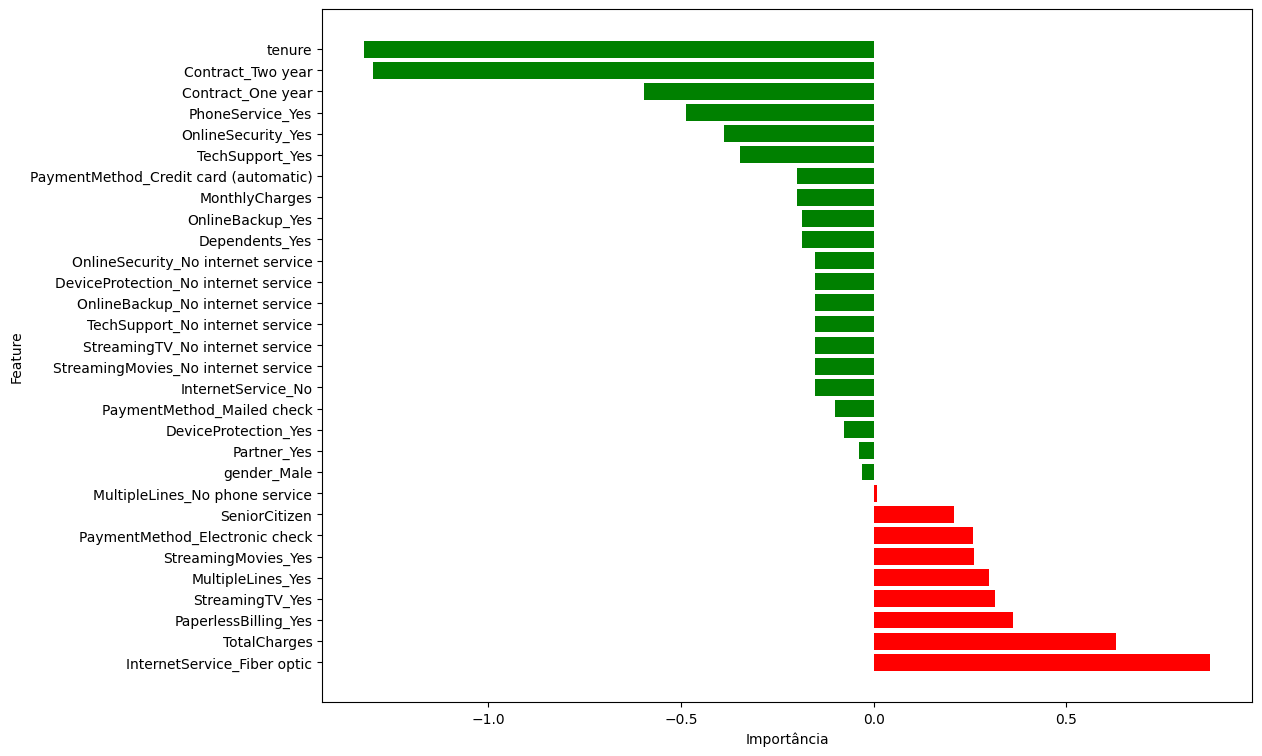

In [32]:
# Gráfico da importância de cada feature
import matplotlib.pyplot as plt

features = X_train.columns
coeficientes = model.coef_[0]

importancias = pd.DataFrame({'Feature': features, 'Coeficiente': coeficientes})
importancias.sort_values(by='Coeficiente', ascending=False, inplace=True)

cores = ['green' if x < 0 else 'red' for x in importancias.Coeficiente]
plt.figure(figsize=(12, 9))
plt.barh(importancias.Feature, importancias.Coeficiente, color=cores)
plt.ylabel("Feature")
plt.xlabel("Importância")
plt.show()

Intuitivamente, clientes de longa data e que optam por planos de maior duração têm menos chance de abandonar a empresa. 
Clientes mais afeitos à tecnologia (consumidores de serviços de streaming e fibra ótica) são expostos a uma gama maior de serviços e, portanto, a mais situações de insatisfação. Além disso é razoável considerar que esses clientes são mais criteriosos com seus planos e têm menos receio em mudar de provedor. 
Um caso curioso é o das variáveis MonthlyCharges e TotalCharges. Claramente existe relação direta entre elas, no entando seus coeficientes têm sinais opostos. 
É razoável pensar em uma relação do tipo TotalCharges ≈ MonthlyCharges x tenure. Note que ambos tenure e MonthlyCharges possuem coeficientes negativos, o que explicaria (mas não justificaria) a inversão de sinal.
Podemos plotar a probabilidade de Churn por TotalCharges e por MonthlyCharges para verificar se os sinais dos coeficientes são apropriados.

<Axes: xlabel='TotalCharges'>

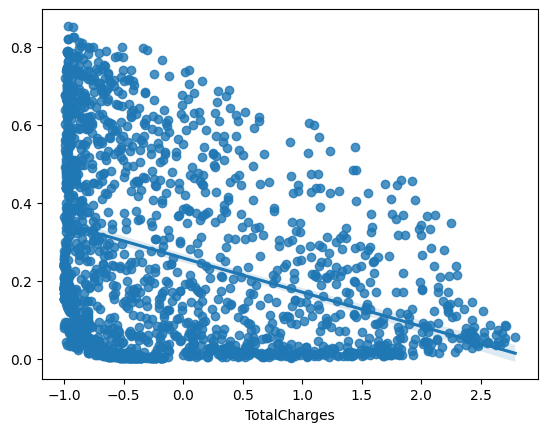

In [33]:
# Probabilidade de Churn por TotalCharges
import seaborn as sns

sns.regplot(x=X_test['TotalCharges'], y=probs)

<Axes: xlabel='MonthlyCharges'>

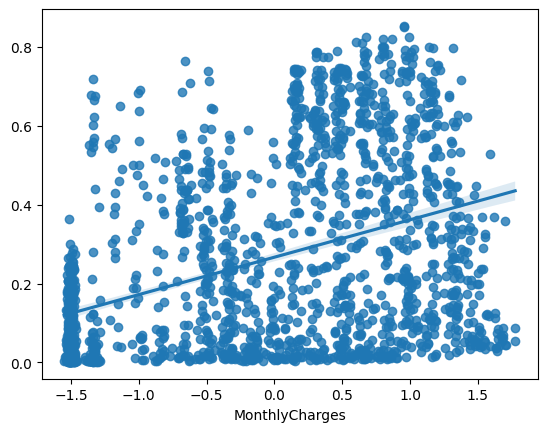

In [34]:
# Probabilidade de Churn por MonthlyCharges
import seaborn as sns

sns.regplot(x=X_test['MonthlyCharges'], y=probs)

**Conclusão**

O objetivo aqui foi criar um ponto de partida pra entender o churn, e o modelo entregou o esperado para um baseline, mas com algumas ressalvas que devem ser tratados no modelo final.
Em particular, as variáveis MonthlyCharges e TotalCharges tiveram coeficientes incoerentes no modelo. Isso é certamente resultado de colinearidade, e pede uma engenharia de features mais robusta. 